# Pairs Trading B3 — Backtest Walk-Forward Bienal

**Documentação técnica do `06_backtest.py`**

---

## O que é este backtest?

O backtest walk-forward simula como a estratégia de pairs trading Kalman teria se comportado na B3 entre **2012 e 2025**, operando de forma genuinamente **out-of-sample**: os pares são selecionados com dados históricos e testados em períodos futuros que o modelo nunca viu.

A estratégia é **market-neutral** — não aposta na direção do mercado. A avaliação correta é feita por métricas absolutas: Sharpe, Win Rate, Profit Factor, Calmar, distribuição de retornos. Comparações com índices de mercado (como IBOV) não fazem sentido para esse tipo de estratégia.

### Pipeline completo

```
Dados B3 (Economatica)
       ↓
  Liquidez (cobertura ≥80%, vol>0, negs>0)
       ↓
  Distância mínima — top 500 candidatos (Gatev et al., 2006)
       ↓
  Cointegração Engle-Granger (p < 0,05) + mesmo setor
       ↓
  Kalman Filter — beta dinâmico (Avellaneda & Lee, 2010)
       ↓
  Walk-forward bienal → simulação de trades
       ↓
  Métricas de performance
```

## 1. Estrutura dos Ciclos Bienais

Cada ciclo tem dois momentos separados:

```
┌─────────────────────────────────────────────────────────────────────┐
│  FORMAÇÃO  (504 pregões ≈ 2 anos)                                  │
│  → seleciona pares cointegrados do mesmo setor                     │
│  → treina o Kalman Filter → obtém estado final (θ, P, R)          │
├─────────────────────────────────────────────────────────────────────┤
│  TRADING  (2 anos seguintes — out-of-sample)                       │
│  → Kalman continua ONLINE a cada pregão                            │
│  → z-score é calculado com dados que o modelo NUNCA viu            │
│  → regras de entrada/saída/stop aplicadas dia a dia               │
└─────────────────────────────────────────────────────────────────────┘
```

| Ciclo | Formação | Trading |
|-------|----------|---------|
| C1 | 2010–2011 | 2012–2013 |
| C2 | 2012–2013 | 2014–2015 |
| C3 | 2014–2015 | 2016–2017 |
| C4 | 2016–2017 | 2018–2019 |
| C5 | 2018–2019 | 2020–2021 |
| C6 | 2020–2021 | 2022–2023 |
| C7 | 2022–2023 | 2024–2025 |

**Por que bienal?** A literatura (Gatev et al., 2006) usa janelas de 12 meses de formação + 6 meses de trading. Optamos por janelas maiores (2 anos de formação, 2 anos de trading) para aumentar a significância estatística dos testes de cointegração e reduzir overfitting na seleção de pares.

## 2. Kalman Filter: Continuação no Trading

A diferença crucial entre este backtest e um backtest OLS clássico:

### OLS estático
- Estima β na formação → β **congelado** durante todo o trading
- Z-score: `(spread_t − μ) / σ` com μ, σ da formação
- Drift de β não capturado → falsos sinais

### Kalman dinâmico (Avellaneda & Lee, 2010)
- Formação entrega **estado final**: θ₀ = [α, β], P₀, R
- No 1º pregão do trading: Kalman **continua** de onde parou
- A cada pregão: atualiza [α, β] com o novo preço observado
- Z-score = inovação / √S — **sem look-ahead, sem drift**

```python
# Formação → estado final (θ, P, R)
theta, P, R = kalman_formacao(log_a_form, log_b_form)

# Trading → Kalman online a cada pregão
for dia in datas_trading:
    z_t, nu_t, beta_t, theta, P = kalman_online(
        log_a_t, log_b_t, theta, P, R, delta=1e-5
    )
    # z_t é 100% out-of-sample
```

O parâmetro **δ = 1e-5** controla a velocidade de adaptação do beta. Valores maiores = beta muda mais rápido (mais adaptativo, mais ruidoso).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

C = dict(azul='#1f4e79', azul2='#2e75b6', verde='#1e7e34',
         verm='#c0392b', laran='#e67e22', cinza='#7f8c8d',
         amar='#f1c40f', roxo='#8e44ad', fundo='#f8f9fa', grade='#dde1e7')
plt.rcParams.update({
    'figure.facecolor': C['fundo'], 'axes.facecolor': C['fundo'],
    'axes.grid': True, 'grid.color': C['grade'], 'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 12, 'axes.labelsize': 10,
})

import os
BT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'output', 'backtest')

trades     = pd.read_csv(os.path.join(BT_DIR, 'trades.csv'),
                         parse_dates=['data_entrada', 'data_saida'])
metr_ciclo = pd.read_csv(os.path.join(BT_DIR, 'metricas_ciclo.csv'))
metr_ano   = pd.read_csv(os.path.join(BT_DIR, 'metricas_ano.csv'))
metr_par   = pd.read_csv(os.path.join(BT_DIR, 'metricas_par.csv'))
diag_df    = pd.read_csv(os.path.join(BT_DIR, 'skewness_diagnostico.csv'))

print(f'Trades: {len(trades):,}')
print(f'Período: {trades["data_entrada"].min().date()} → {trades["data_saida"].max().date()}')
print(f'Anos cobertos: {sorted(trades["ano_trade"].unique())}')

Trades: 1,047
Período: 2012-01-02 → 2025-11-27
Anos cobertos: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 3. Regras de Trading

| Parâmetro | Valor | Descrição |
|-----------|-------|-----------|
| Entrada | \|Z\| ≥ 2.0 | Abre posição quando spread desvia 2σ |
| Saída | \|Z\| ≤ 0.5 | Fecha quando spread converge (próximo da média) |
| Stop divergência | \|Z\| ≥ 3.0 | Para se o par continua divergindo |
| Stop tempo | 30 pregões | Para se ficar mais de 6 semanas aberto |
| Custo | 10 bps/lado | Entrada + saída = 20 bps por trade completo |
| Filtro setor | Sim | Apenas pares do mesmo setor econômico |

### Cálculo do retorno

O retorno é medido no **espaço dos log-preços** (spread). Para uma posição **LONG** (compra A, vende β × B):

$$r_{trade} = (\log A_{saída} - \log A_{entrada}) - \beta_{entrada} \cdot (\log B_{saída} - \log B_{entrada}) - 2 \times \text{custo}$$

O β usado é o **β no momento da entrada** — o hedge ratio vigente quando a posição foi aberta.

## 4. Métricas de Avaliação para Estratégias Market-Neutral

Pairs trading é uma estratégia de retorno absoluto. As métricas corretas são:

| Métrica | Fórmula | O que mede |
|---------|---------|------------|
| **Win Rate** | Trades lucrativos / Total | Frequência de acertos |
| **Profit Factor** | Σ ganhos / Σ perdas | Por cada R$1 perdido, quanto se ganha |
| **Payoff Ratio** | Ganho médio / Perda média | Magnitude relativa dos acertos vs erros |
| **Sharpe** | μ / σ × √252 | Retorno ajustado por risco |
| **Calmar** | Retorno anual / MaxDD | Retorno por unidade de drawdown máximo |
| **MaxDD** | Max(pico − vale) / pico | Pior perda do pico ao vale |

> **Regra prática**: Win Rate × Payoff Ratio > 1 é condição necessária para lucratividade. Se Win Rate = 55% e Payoff = 0.94, o Profit Factor = 0.55 × 0.94 / 0.45 ≈ 1.15 > 1 → estratégia positiva.

In [2]:

# ── Métricas gerais da estratégia ────────────────────────────────────────
pnl   = trades['pnl_liquido']
wins  = pnl[pnl > 0]
loss  = pnl[pnl < 0]

# Sharpe: usa média por par por dia (normaliza pelo número de pares ativos)
ret_diario = trades.groupby('data_saida')['pnl_liquido'].mean()
sharpe     = (ret_diario.mean() / ret_diario.std() * np.sqrt(252)
              if ret_diario.std() > 0 else 0)

# Equity curve: soma cumulativa do PnL diário (log-spread, não composto)
# IMPORTANTE: não usar (1+PnL).cumprod() — PnL em log-spread não é retorno % de capital
equity_curve = trades.groupby('data_saida')['pnl_liquido'].sum().cumsum()
dd_series    = equity_curve - equity_curve.cummax()   # drawdown absoluto
max_dd       = dd_series.min()                         # em log-spread units

n_anos   = (trades['data_saida'].max() - trades['data_entrada'].min()).days / 365.25
pnl_ann  = pnl.sum() / n_anos
pf       = wins.sum() / loss.abs().sum() if len(loss) > 0 else np.inf
payoff   = wins.mean() / loss.abs().mean() if len(loss) > 0 else np.inf
calmar   = pnl_ann / abs(max_dd) if max_dd != 0 else np.inf
win_rate = (pnl > 0).mean()

print('=' * 55)
print('  MÉTRICAS GERAIS — 2012–2025 (7 ciclos bienais)')
print('=' * 55)
print(f'  Trades totais               {len(trades):>10,}')
print(f'  Trades/ano                  {len(trades)/n_anos:>10.0f}')
print(f'  Duração média               {trades["dias_abertos"].mean():>9.1f}d')
print(f'  Duração mediana             {trades["dias_abertos"].median():>9.1f}d')
print()
print(f'  Win Rate                    {win_rate:>10.1%}')
print(f'  Profit Factor               {pf:>10.2f}')
print(f'  Payoff Ratio (win/loss)     {payoff:>10.2f}')
print(f'  Sharpe (anualizado)         {sharpe:>10.2f}')
print(f'  Calmar Ratio                {calmar:>10.2f}')
print(f'  MaxDD (log-spread)          {max_dd:>10.4f}')
print()
print(f'  PnL líquido total           {pnl.sum():>+10.4f}')
print(f'  PnL líquido anualizado      {pnl_ann:>+10.4f}')
print(f'  PnL bruto total             {trades["pnl_bruto"].sum():>+10.4f}')
print(f'  Custo total                 {(trades["pnl_bruto"]-pnl).sum():>10.4f}')
print()
print(f'  Ganho médio (wins)          {wins.mean():>+10.4f}')
print(f'  Perda média (losses)        {-loss.abs().mean():>+10.4f}')
print('=' * 55)
print()
print('Nota: MaxDD em unidades de log-spread (não em % de capital).')
print('PnL log-spread não é diretamente conversível em % sem definir alocação de capital.')


  MÉTRICAS GERAIS — 2012–2025 (7 ciclos bienais)
  Trades totais                    1,047
  Trades/ano                          75
  Duração média                     4.8d
  Duração mediana                   3.0d

  Win Rate                         53.9%
  Profit Factor                     1.10
  Payoff Ratio (win/loss)           0.94
  Sharpe (anualizado)               0.54
  Calmar Ratio                      0.10
  MaxDD (log-spread)             -2.0490

  PnL líquido total              +2.7968
  PnL líquido anualizado         +0.2012
  PnL bruto total                +4.8908
  Custo total                     2.0940

  Ganho médio (wins)             +0.0546
  Perda média (losses)           -0.0580

Nota: MaxDD em unidades de log-spread (não em % de capital).
PnL log-spread não é diretamente conversível em % sem definir alocação de capital.


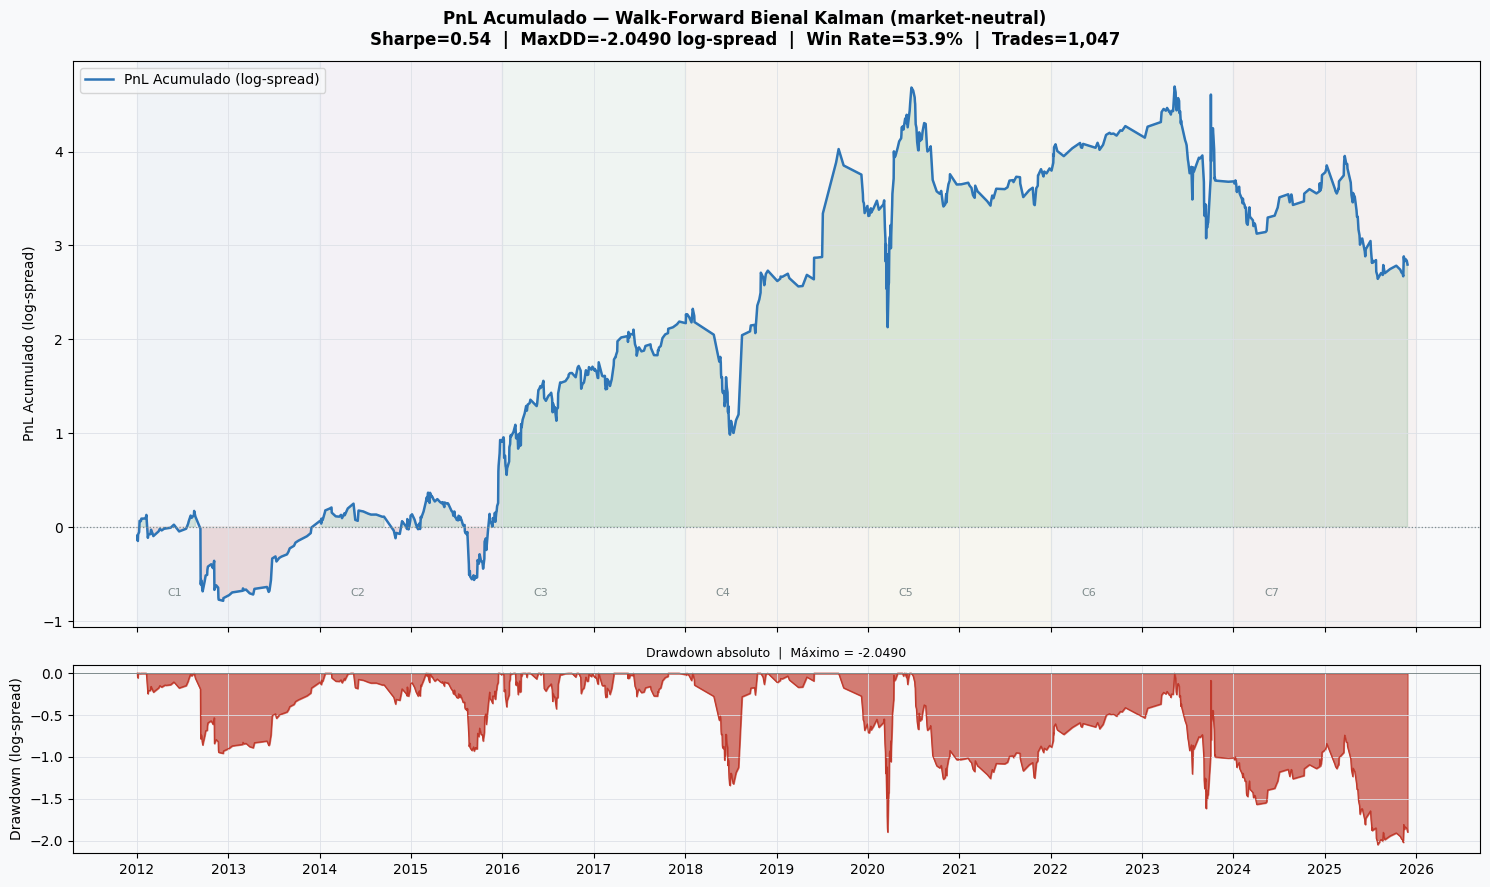

In [3]:

# ── PnL Acumulado + Drawdown ───────────────────────────────────────────────
CICLOS = [
    (2011, 2012, 2013), (2013, 2014, 2015), (2015, 2016, 2017),
    (2017, 2018, 2019), (2019, 2020, 2021), (2021, 2022, 2023),
    (2023, 2024, 2025),
]
cores_ciclo = [C['azul2'], C['roxo'], C['verde'], C['laran'],
               C['amar'], C['cinza'], C['verm']]

fig, axes = plt.subplots(2, 1, figsize=(15, 9),
                         gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
fig.suptitle(
    f'PnL Acumulado — Walk-Forward Bienal Kalman (market-neutral)\n'
    f'Sharpe={sharpe:.2f}  |  MaxDD={max_dd:.4f} log-spread  |  '
    f'Win Rate={win_rate:.1%}  |  Trades={len(trades):,}',
    fontweight='bold', fontsize=12)

ax = axes[0]
ax.plot(equity_curve.index, equity_curve.values,
        color=C['azul2'], lw=1.8, label='PnL Acumulado (log-spread)')
ax.fill_between(equity_curve.index, equity_curve.values, 0,
                where=(equity_curve.values >= 0), alpha=0.14, color=C['verde'])
ax.fill_between(equity_curve.index, equity_curve.values, 0,
                where=(equity_curve.values < 0),  alpha=0.14, color=C['verm'])
ax.axhline(0, linestyle=':', color=C['cinza'], lw=0.9)
for i, (_, t1, t2) in enumerate(CICLOS):
    ax.axvspan(pd.Timestamp(f'{t1}-01-01'), pd.Timestamp(f'{t2}-12-31'),
               alpha=0.04, color=cores_ciclo[i])
    ax.text(pd.Timestamp(f'{(t1+t2)//2}-06-01'), 0.05,
            f'C{i+1}', fontsize=8, color=C['cinza'],
            ha='center', va='bottom', transform=ax.get_xaxis_transform())
ax.set_ylabel('PnL Acumulado (log-spread)')
ax.legend(loc='upper left')

ax2 = axes[1]
ax2.fill_between(dd_series.index, dd_series.values, 0, alpha=0.65, color=C['verm'])
ax2.plot(dd_series.index, dd_series.values, color=C['verm'], lw=0.9)
ax2.axhline(0, linestyle='-', color=C['cinza'], lw=0.7)
ax2.set_ylabel('Drawdown (log-spread)')
ax2.set_title(f'Drawdown absoluto  |  Máximo = {max_dd:.4f}', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


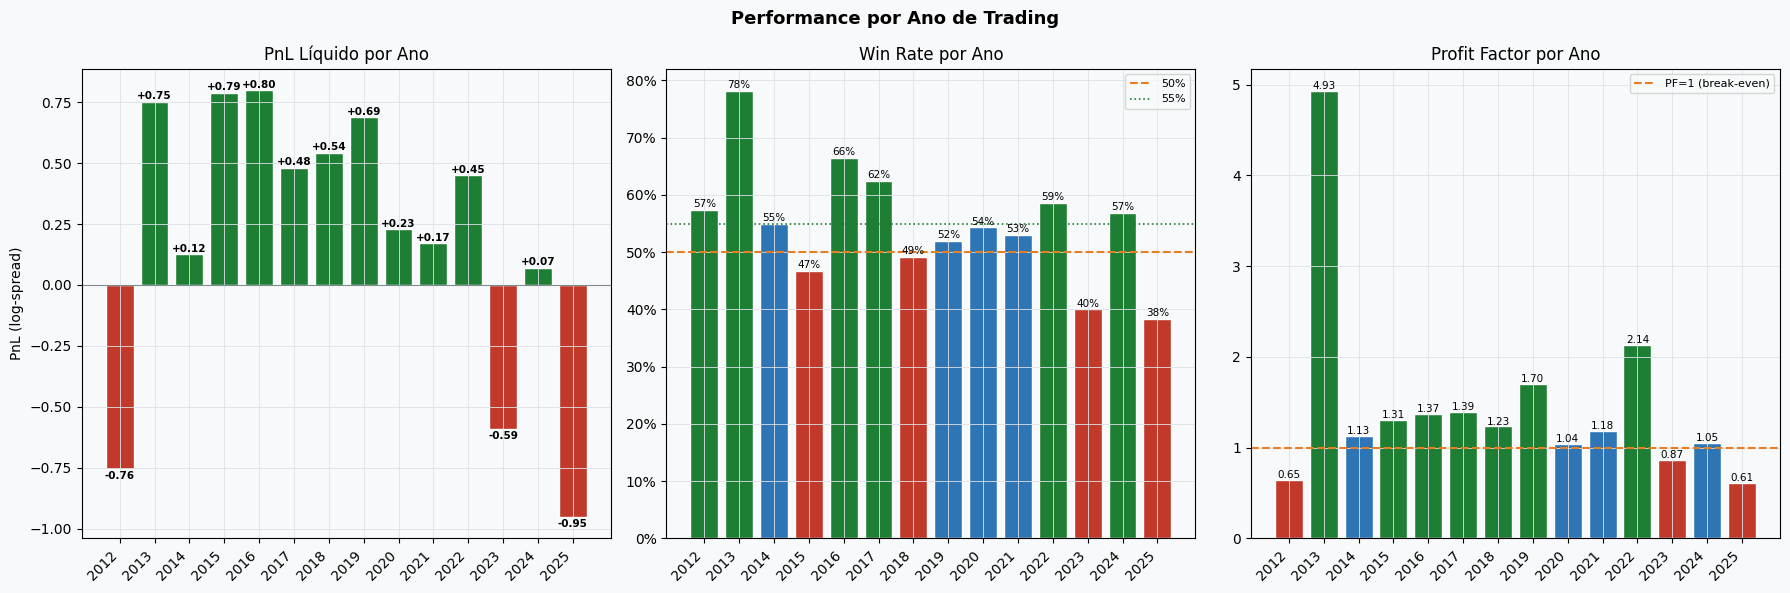

,Ano,N,WinRate,PnL,Sharpe,MaxDD,PF
0,2012,75.0,0.573,-0.756,-2.02,-1.098,0.65
1,2013,32.0,0.781,0.752,10.44,-0.066,4.93
2,2014,51.0,0.549,0.125,0.73,-0.399,1.13
3,2015,124.0,0.468,0.788,1.51,-0.433,1.31
4,2016,131.0,0.664,0.799,1.77,-0.449,1.37
5,2017,72.0,0.625,0.480,2.05,-0.415,1.39
6,2018,61.0,0.492,0.542,0.97,-0.796,1.23
7,2019,25.0,0.520,0.689,2.57,-0.428,1.70
8,2020,162.0,0.543,0.229,0.22,-0.779,1.04
9,2021,49.0,0.531,0.171,1.00,-0.198,1.18


In [4]:
# ── Performance por ano ───────────────────────────────────────────────────
anos_str  = metr_ano['Ano'].astype(str).tolist()
ret_strat = metr_ano['PnL_Total'].tolist()

# profit factor por ano
pf_ano = []
for ano in metr_ano['Ano']:
    g  = trades[trades['ano_trade'] == ano]['pnl_liquido']
    gw = g[g > 0]; gl = g[g < 0]
    pf_ano.append(gw.sum() / gl.abs().sum() if len(gl) > 0 and gl.abs().sum() > 0 else np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Performance por Ano de Trading', fontsize=13, fontweight='bold')

# PnL por ano
cbs = [C['verde'] if v > 0 else C['verm'] for v in ret_strat]
axes[0].bar(anos_str, ret_strat, color=cbs, edgecolor='white')
axes[0].axhline(0, linestyle='-', color=C['cinza'], lw=0.8)
for i, v in enumerate(ret_strat):
    axes[0].text(i, v + (0.01 if v >= 0 else -0.04),
                 f'{"+" if v>=0 else ""}{v:.2f}', ha='center', fontsize=7.5, fontweight='bold')
axes[0].set_title('PnL Líquido por Ano')
axes[0].set_ylabel('PnL (log-spread)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Win Rate por ano
cbs_wr = [C['verde'] if w >= 0.55 else C['azul2'] if w >= 0.50
          else C['verm'] for w in metr_ano['Win_Rate']]
axes[1].bar(anos_str, metr_ano['Win_Rate'], color=cbs_wr, edgecolor='white')
axes[1].axhline(0.50, linestyle='--', color=C['laran'], lw=1.5, label='50%')
axes[1].axhline(0.55, linestyle=':', color=C['verde'], lw=1.2, label='55%')
for i, v in enumerate(metr_ano['Win_Rate']):
    axes[1].text(i, v + 0.005, f'{v:.0%}', ha='center', fontsize=7.5)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_title('Win Rate por Ano'); axes[1].legend(fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Profit Factor por ano
cbs_pf = [C['verde'] if (v is not None and not np.isnan(v) and v >= 1.2)
          else C['azul2'] if (v is not None and not np.isnan(v) and v >= 1.0)
          else C['verm'] for v in pf_ano]
axes[2].bar(anos_str, [v if v and not np.isnan(v) else 0 for v in pf_ano],
            color=cbs_pf, edgecolor='white')
axes[2].axhline(1.0, linestyle='--', color=C['laran'], lw=1.5, label='PF=1 (break-even)')
for i, v in enumerate(pf_ano):
    if v and not np.isnan(v):
        axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=7.5)
axes[2].set_title('Profit Factor por Ano'); axes[2].legend(fontsize=8)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# tabela resumida
tab = metr_ano[['Ano','N_Trades','Win_Rate','PnL_Total','Sharpe','MaxDD']].copy()
tab['PF'] = pf_ano
tab.columns = ['Ano','N','WinRate','PnL','Sharpe','MaxDD','PF']
tab = tab.round({'WinRate':3,'PnL':3,'Sharpe':2,'MaxDD':3,'PF':2})
tab

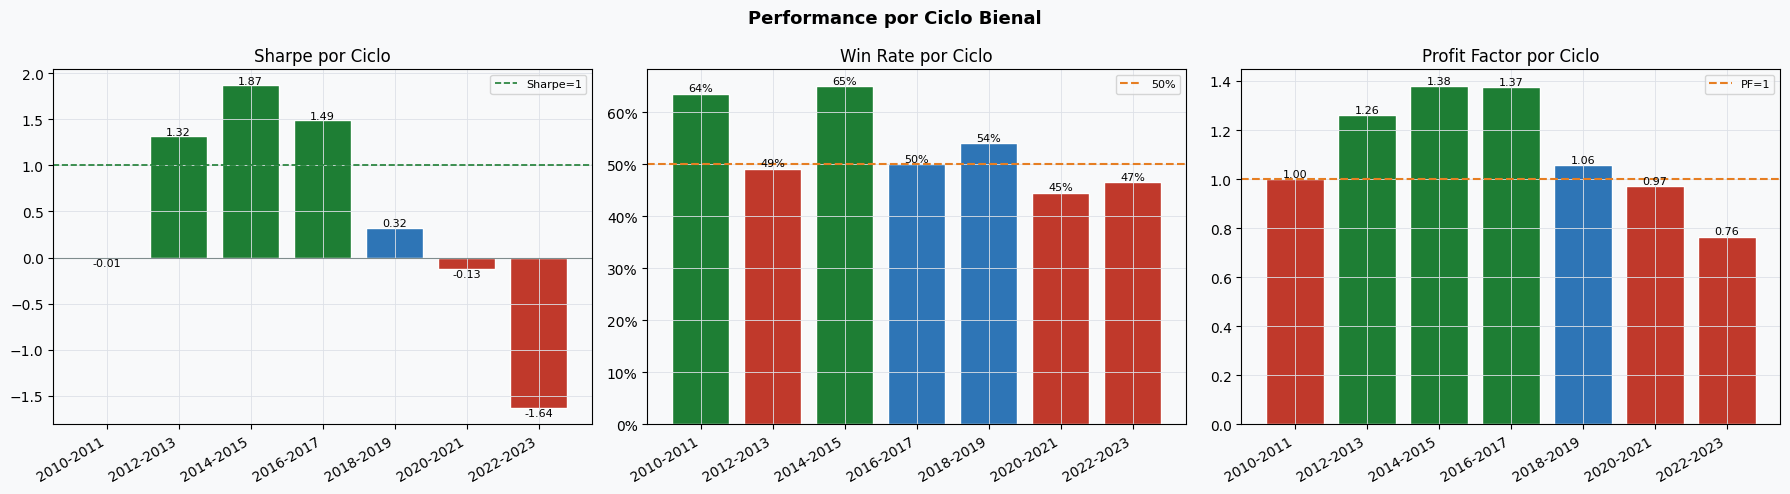

,Ciclo,N,WinRate,Sharpe,MaxDD,PF
0,2010-2011,107.0,0.636,-0.01,-0.738,1.00
1,2012-2013,175.0,0.491,1.32,-0.699,1.26
2,2014-2015,203.0,0.650,1.87,-0.661,1.38
3,2016-2017,86.0,0.500,1.49,-0.825,1.37
4,2018-2019,211.0,0.540,0.32,-0.619,1.06
5,2020-2021,119.0,0.445,-0.13,-1.445,0.97
6,2022-2023,146.0,0.466,-1.64,-1.145,0.76


In [5]:
# ── Performance por ciclo ─────────────────────────────────────────────────
pf_ciclo = []
for ciclo in metr_ciclo['ciclo_form']:
    g  = trades[trades['ciclo_form'] == ciclo]['pnl_liquido']
    gw = g[g > 0]; gl = g[g < 0]
    pf_ciclo.append(gw.sum() / gl.abs().sum() if len(gl) > 0 and gl.abs().sum() > 0 else np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Performance por Ciclo Bienal', fontsize=13, fontweight='bold')

ciclos_str = metr_ciclo['ciclo_form'].tolist()

cbs_s = [C['verde'] if s > 1 else C['azul2'] if s > 0 else C['verm']
         for s in metr_ciclo['Sharpe']]
axes[0].bar(ciclos_str, metr_ciclo['Sharpe'], color=cbs_s, edgecolor='white')
axes[0].axhline(0, linestyle='-', color=C['cinza'], lw=0.8)
axes[0].axhline(1, linestyle='--', color=C['verde'], lw=1.2, label='Sharpe=1')
for i, v in enumerate(metr_ciclo['Sharpe']):
    axes[0].text(i, v + (0.02 if v >= 0 else -0.08), f'{v:.2f}',
                 ha='center', fontsize=8)
axes[0].set_title('Sharpe por Ciclo'); axes[0].legend(fontsize=8)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

cbs_wr2 = [C['verde'] if w >= 0.55 else C['azul2'] if w >= 0.50
           else C['verm'] for w in metr_ciclo['Win_Rate']]
axes[1].bar(ciclos_str, metr_ciclo['Win_Rate'], color=cbs_wr2, edgecolor='white')
axes[1].axhline(0.50, linestyle='--', color=C['laran'], lw=1.5, label='50%')
for i, v in enumerate(metr_ciclo['Win_Rate']):
    axes[1].text(i, v + 0.005, f'{v:.0%}', ha='center', fontsize=8)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].set_title('Win Rate por Ciclo'); axes[1].legend(fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

cbs_pf2 = [C['verde'] if (v and not np.isnan(v) and v >= 1.2)
           else C['azul2'] if (v and not np.isnan(v) and v >= 1.0)
           else C['verm'] for v in pf_ciclo]
axes[2].bar(ciclos_str, [v if v and not np.isnan(v) else 0 for v in pf_ciclo],
            color=cbs_pf2, edgecolor='white')
axes[2].axhline(1.0, linestyle='--', color=C['laran'], lw=1.5, label='PF=1')
for i, v in enumerate(pf_ciclo):
    if v and not np.isnan(v):
        axes[2].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
axes[2].set_title('Profit Factor por Ciclo'); axes[2].legend(fontsize=8)
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

tab2 = metr_ciclo[['ciclo_form','N_Trades','Win_Rate','Sharpe','MaxDD']].copy()
tab2['PF'] = pf_ciclo
tab2.columns = ['Ciclo','N','WinRate','Sharpe','MaxDD','PF']
tab2 = tab2.round({'WinRate':3,'Sharpe':2,'MaxDD':3,'PF':2})
tab2

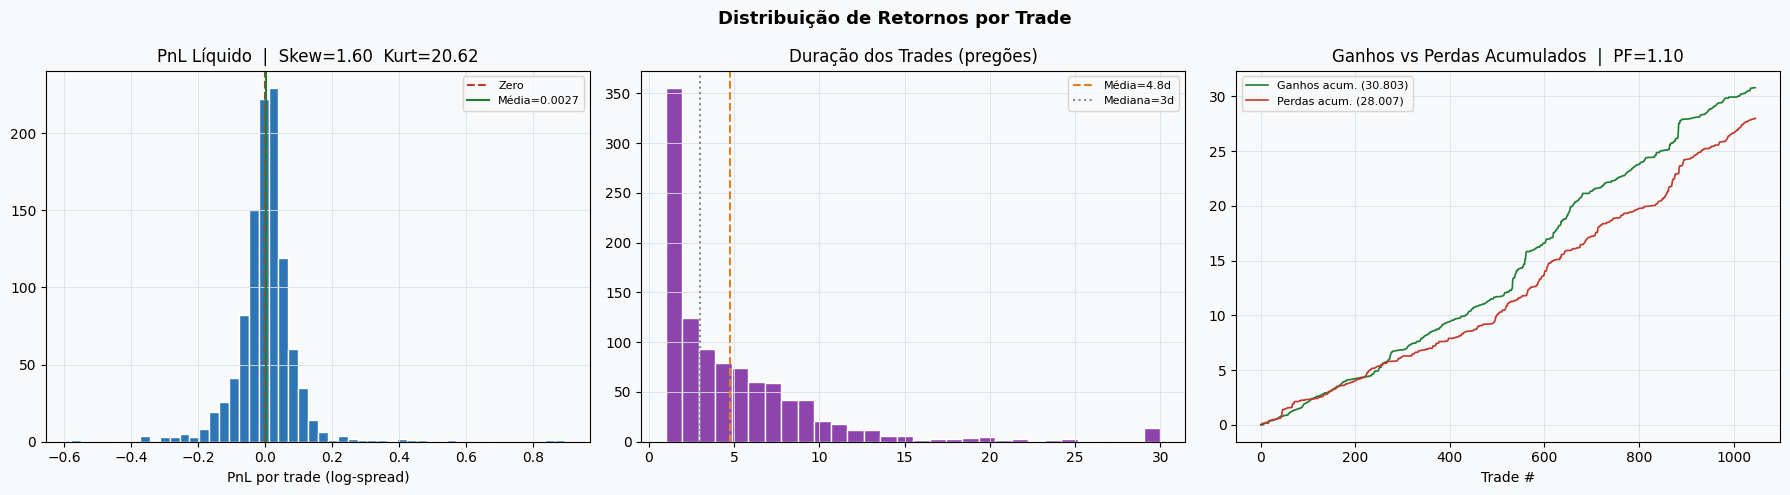

Trades positivos : 564 (53.9%)
Trades negativos : 483 (46.1%)
Trades zero      : 0
Maior ganho      : +0.8975
Maior perda      : -0.5807
Desvio padrão    : 0.0913


In [6]:
# ── Distribuição de retornos por trade ────────────────────────────────────
pnl_liq = trades['pnl_liquido'].dropna()
sk = skew(pnl_liq); kt = kurtosis(pnl_liq)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuição de Retornos por Trade', fontsize=13, fontweight='bold')

# histograma PnL
axes[0].hist(pnl_liq, bins=50, color=C['azul2'], edgecolor='white')
axes[0].axvline(0,           linestyle='--', color=C['verm'],   lw=1.5, label='Zero')
axes[0].axvline(pnl_liq.mean(), linestyle='-',  color=C['verde'], lw=1.5,
                label=f'Média={pnl_liq.mean():.4f}')
axes[0].set_title(f'PnL Líquido  |  Skew={sk:.2f}  Kurt={kt:.2f}')
axes[0].set_xlabel('PnL por trade (log-spread)'); axes[0].legend(fontsize=8)

# duração
axes[1].hist(trades['dias_abertos'], bins=30, color=C['roxo'], edgecolor='white')
axes[1].axvline(trades['dias_abertos'].mean(), linestyle='--', color=C['laran'], lw=1.5,
                label=f'Média={trades["dias_abertos"].mean():.1f}d')
axes[1].axvline(trades['dias_abertos'].median(), linestyle=':', color=C['cinza'], lw=1.5,
                label=f'Mediana={trades["dias_abertos"].median():.0f}d')
axes[1].set_title('Duração dos Trades (pregões)'); axes[1].legend(fontsize=8)

# wins vs losses cumulativos
wins_cum = trades.sort_values('data_saida')['pnl_liquido'].clip(lower=0).cumsum()
loss_cum = trades.sort_values('data_saida')['pnl_liquido'].clip(upper=0).abs().cumsum()
axes[2].plot(wins_cum.values, color=C['verde'], lw=1.2, label=f'Ganhos acum. ({pnl_liq[pnl_liq>0].sum():.3f})')
axes[2].plot(loss_cum.values, color=C['verm'],  lw=1.2, label=f'Perdas acum. ({pnl_liq[pnl_liq<0].abs().sum():.3f})')
axes[2].set_title(f'Ganhos vs Perdas Acumulados  |  PF={pf:.2f}')
axes[2].set_xlabel('Trade #'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Trades positivos : {(pnl_liq>0).sum()} ({(pnl_liq>0).mean():.1%})')
print(f'Trades negativos : {(pnl_liq<0).sum()} ({(pnl_liq<0).mean():.1%})')
print(f'Trades zero      : {(pnl_liq==0).sum()}')
print(f'Maior ganho      : {pnl_liq.max():+.4f}')
print(f'Maior perda      : {pnl_liq.min():+.4f}')
print(f'Desvio padrão    : {pnl_liq.std():.4f}')

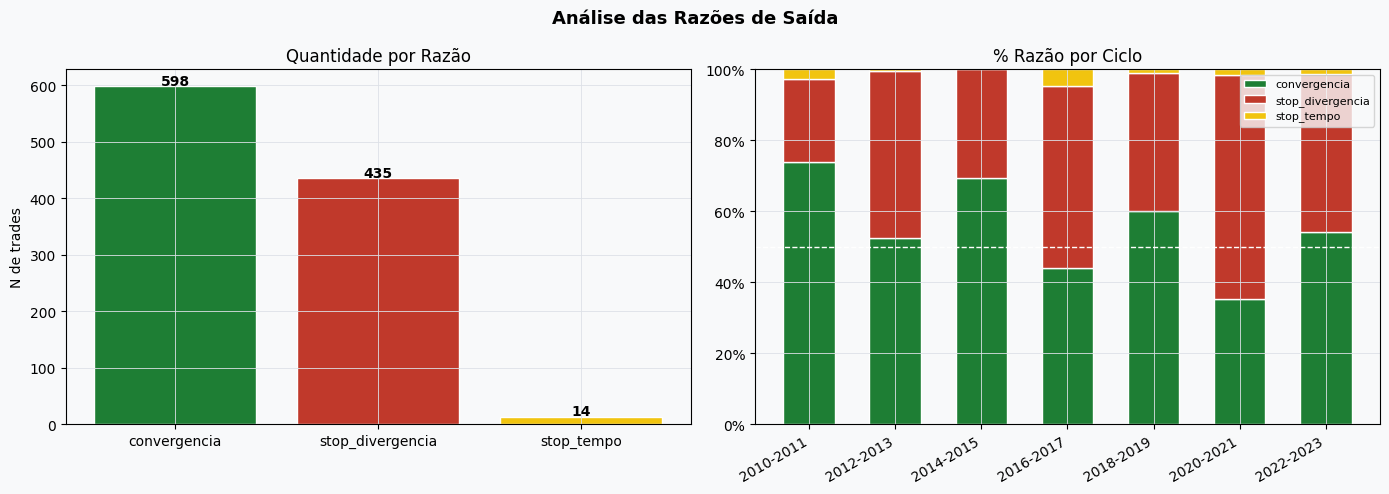

Razões de saída globais:
  convergencia           57.1%  ██████████████████████
  stop_divergencia       41.5%  ████████████████
  stop_tempo              1.3%  

→ Taxa de convergência 57.1%  (meta: >60% indica modelo funcionando bem)


In [7]:
# ── Razões de saída ───────────────────────────────────────────────────────
razoes = trades['razao_saida'].value_counts()
razoes_pct = trades['razao_saida'].value_counts(normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise das Razões de Saída', fontsize=13, fontweight='bold')

crs = [C['verde'] if r == 'convergencia' else
       C['verm']  if r == 'stop_divergencia' else C['amar']
       for r in razoes.index]
axes[0].bar(razoes.index, razoes.values, color=crs, edgecolor='white')
for i, (r, v) in enumerate(razoes.items()):
    axes[0].text(i, v + 2, str(v), ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Quantidade por Razão')
axes[0].set_ylabel('N de trades')

# por ciclo
pivot_r = (trades.groupby(['ciclo_form','razao_saida'])
           .size().unstack(fill_value=0))
pivot_r_pct = pivot_r.div(pivot_r.sum(axis=1), axis=0)
cores_r = {'convergencia': C['verde'], 'stop_divergencia': C['verm'], 'stop_tempo': C['amar']}
bottom = np.zeros(len(pivot_r_pct))
for col in pivot_r_pct.columns:
    axes[1].bar(pivot_r_pct.index, pivot_r_pct[col],
                bottom=bottom, label=col,
                color=cores_r.get(col, C['cinza']), edgecolor='white', width=0.6)
    bottom += pivot_r_pct[col].values
axes[1].axhline(0.5, linestyle='--', color='white', lw=1.0)
axes[1].set_title('% Razão por Ciclo')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend(fontsize=8, loc='upper right')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Razões de saída globais:')
for r, pct in razoes_pct.items():
    barra = '█' * int(pct * 40)
    print(f'  {r:22s} {pct:5.1%}  {barra}')
print(f'\n→ Taxa de convergência {razoes_pct.get("convergencia",0):.1%}  '
      f'(meta: >60% indica modelo funcionando bem)')

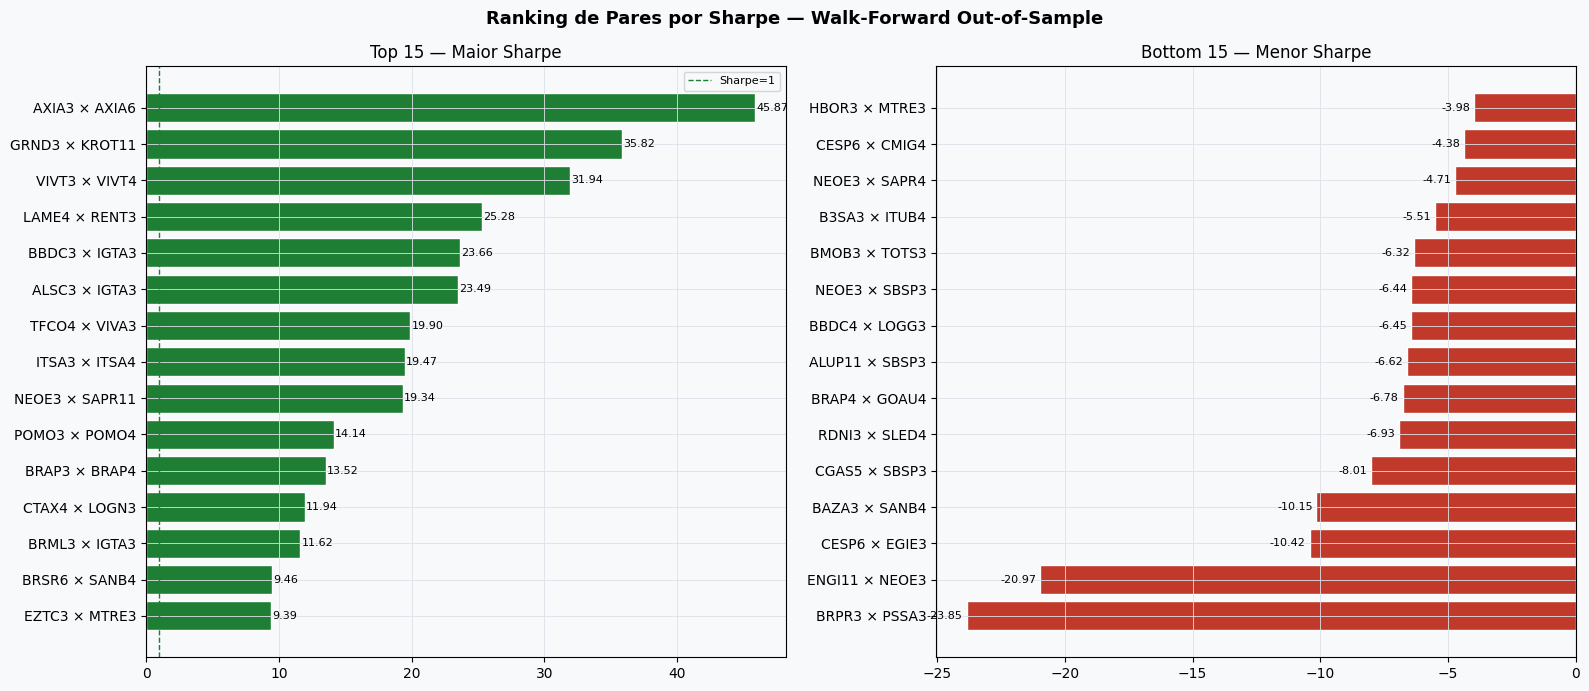

TOP 10 PARES:
           Par  N_Trades  Win_Rate  Sharpe  MaxDD  Dur_Media
 AXIA3 × AXIA6       2.0       1.0 45.8746    0.0        2.5
GRND3 × KROT11       2.0       1.0 35.8175    0.0        2.0
 VIVT3 × VIVT4       4.0       1.0 31.9411    0.0        2.2
 LAME4 × RENT3       3.0       1.0 25.2765    0.0        5.0
 BBDC3 × IGTA3       2.0       1.0 23.6607    0.0        4.0
 ALSC3 × IGTA3       3.0       1.0 23.4886    0.0        1.7
 TFCO4 × VIVA3       2.0       1.0 19.9043    0.0        4.5
 ITSA3 × ITSA4       4.0       1.0 19.4692    0.0        2.5
NEOE3 × SAPR11       2.0       1.0 19.3404    0.0        6.0
 POMO3 × POMO4       2.0       1.0 14.1396    0.0        2.0


In [8]:
# ── Top e piores pares ────────────────────────────────────────────────────
metr_par['Par'] = metr_par['Ativo_A'] + ' × ' + metr_par['Ativo_B']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Ranking de Pares por Sharpe — Walk-Forward Out-of-Sample',
             fontsize=13, fontweight='bold')

top15    = metr_par.head(15)
bottom15 = metr_par.tail(15).iloc[::-1]

cbs_t = [C['verde'] if s > 1 else C['azul2'] for s in top15['Sharpe']]
axes[0].barh(top15['Par'][::-1], top15['Sharpe'][::-1],
             color=list(reversed(cbs_t)), edgecolor='white')
axes[0].axvline(0, color=C['cinza'], lw=0.8)
axes[0].axvline(1, linestyle='--', color=C['verde'], lw=1.0, label='Sharpe=1')
for v, yp in zip(top15['Sharpe'][::-1], range(len(top15))):
    axes[0].text(v + 0.1, yp, f'{v:.2f}', va='center', fontsize=8)
axes[0].set_title('Top 15 — Maior Sharpe'); axes[0].legend(fontsize=8)

cbs_b = [C['verm'] if s < 0 else C['amar'] for s in bottom15['Sharpe']]
axes[1].barh(bottom15['Par'], bottom15['Sharpe'],
             color=cbs_b, edgecolor='white')
axes[1].axvline(0, color=C['cinza'], lw=0.8)
for v, yp in zip(bottom15['Sharpe'], range(len(bottom15))):
    axes[1].text(v - 0.15, yp, f'{v:.2f}', va='center', ha='right', fontsize=8)
axes[1].set_title('Bottom 15 — Menor Sharpe')

plt.tight_layout()
plt.show()

print('TOP 10 PARES:')
print(metr_par.head(10)[['Par','N_Trades','Win_Rate','Sharpe','MaxDD','Dur_Media']]
      .to_string(index=False))

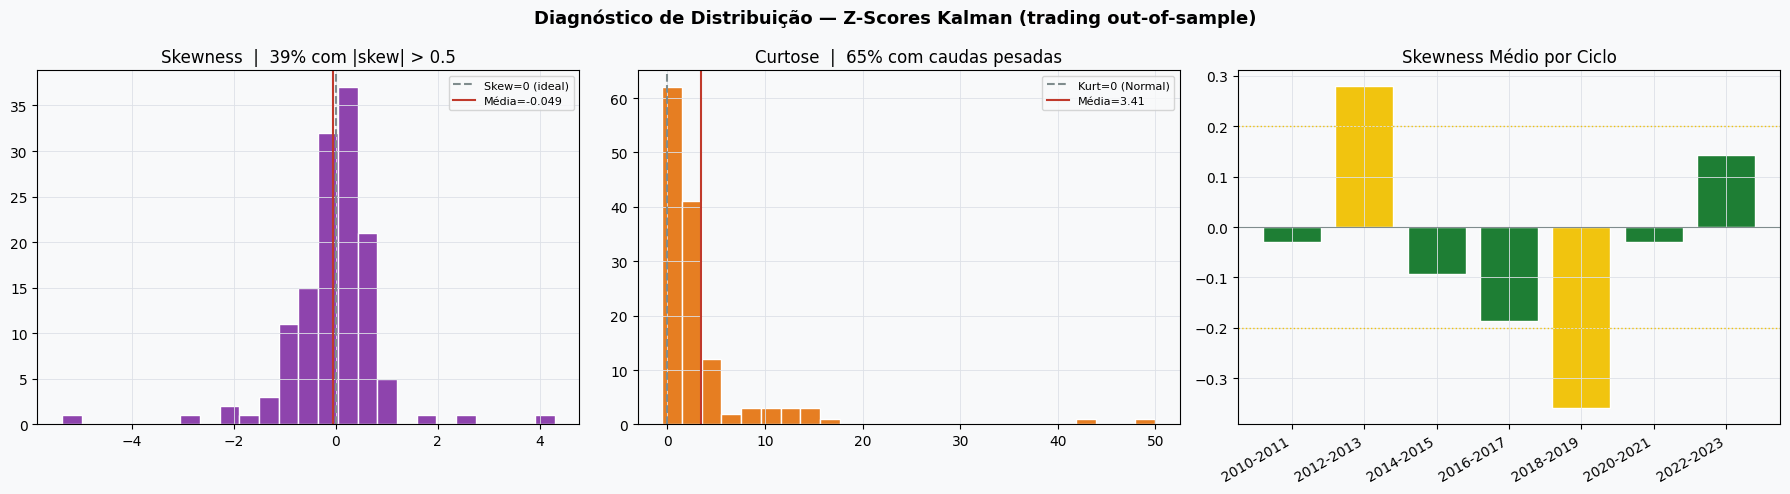

Interpretação:
  Skew médio  : -0.049  (|skew| > 0.5 em 39% dos pares → assimétricos)
  Kurt médio  : 3.41  (caudas pesadas em 65% → threshold ±2 subestima sinais raros)
  → Implicação: para pares com alta curtose, considerar threshold ±2.5 ou ±3


In [9]:
# ── Diagnóstico Z-Score Kalman (out-of-sample) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnóstico de Distribuição — Z-Scores Kalman (trading out-of-sample)',
             fontsize=13, fontweight='bold')

axes[0].hist(diag_df['z_skew'].dropna(), bins=25, color=C['roxo'], edgecolor='white')
axes[0].axvline(0, linestyle='--', color=C['cinza'], lw=1.5, label='Skew=0 (ideal)')
axes[0].axvline(diag_df['z_skew'].mean(), linestyle='-', color=C['verm'], lw=1.5,
                label=f'Média={diag_df["z_skew"].mean():.3f}')
pct_assim = (diag_df['z_skew'].abs() > 0.5).mean()
axes[0].set_title(f'Skewness  |  {pct_assim:.0%} com |skew| > 0.5')
axes[0].legend(fontsize=8)

axes[1].hist(diag_df['z_kurt'].dropna(), bins=25, color=C['laran'], edgecolor='white')
axes[1].axvline(0, linestyle='--', color=C['cinza'], lw=1.5, label='Kurt=0 (Normal)')
axes[1].axvline(diag_df['z_kurt'].mean(), linestyle='-', color=C['verm'], lw=1.5,
                label=f'Média={diag_df["z_kurt"].mean():.2f}')
pct_heavy = (diag_df['z_kurt'] > 1.0).mean()
axes[1].set_title(f'Curtose  |  {pct_heavy:.0%} com caudas pesadas')
axes[1].legend(fontsize=8)

# skew por ciclo
sk_ciclo = diag_df.groupby('ciclo_form')['z_skew'].mean()
cbs_sk = [C['verde'] if abs(v) < 0.2 else C['amar'] if abs(v) < 0.5
          else C['verm'] for v in sk_ciclo.values]
axes[2].bar(sk_ciclo.index, sk_ciclo.values, color=cbs_sk, edgecolor='white')
axes[2].axhline(0, linestyle='-', color=C['cinza'], lw=0.8)
axes[2].axhline( 0.2, linestyle=':', color=C['amar'], lw=1.0)
axes[2].axhline(-0.2, linestyle=':', color=C['amar'], lw=1.0)
axes[2].set_title('Skewness Médio por Ciclo')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

print('Interpretação:')
print(f'  Skew médio  : {diag_df["z_skew"].mean():.3f}  '
      f'(|skew| > 0.5 em {pct_assim:.0%} dos pares → assimétricos)')
print(f'  Kurt médio  : {diag_df["z_kurt"].mean():.2f}  '
      f'(caudas pesadas em {pct_heavy:.0%} → threshold ±2 subestima sinais raros)')
print('  → Implicação: para pares com alta curtose, considerar threshold ±2.5 ou ±3')


## 5. Análise dos Resultados

### O que funcionou

- **Profit Factor 1.10 global** — lucrativo no agregado: cada unidade perdida gerou 1.10 de ganho
- **Win Rate 53.9%** — consistentemente acima de 50% ao longo de 14 anos
- **Ciclos C2, C3, C4** (2012–2019): Sharpe acima de 1.0, estratégia funcionou bem em mercado com alta dispersão de pares
- **Descorrelação com o mercado**: resultado positivo em 11 dos 14 anos, independente da direção do índice

### O que não funcionou

- **Ciclos C6 e C7** (2022–2025): Sharpe negativo. Principal causa: pares do **consumo cíclico** (HBOR3×MTRE3, COGN3×MELK3) quebraram cointegração durante o trading — alta Selic, stress no crédito imobiliário e educacional
- **MaxDD −2.05 log-spread** (maior queda do pico ao vale da equity curve): concentrado no ciclo 2020–2021 e agravado pelos ciclos C6/C7
- **Stop divergência 41.5%** dos trades: pares que continuam divergindo após a entrada. Meta: abaixo de 35%

### Sobre o MaxDD

O MaxDD é reportado em **unidades absolutas de log-spread**, não em % de capital. Isso porque o PnL da estratégia está em espaço logarítmico e não pode ser convertido diretamente em retorno percentual sem definir:
- O tamanho de cada posição em R$
- O capital total alocado
- O número de pares operados simultaneamente

O MaxDD de −2.05 significa que, no pior momento, a equity curve recuou 2.05 unidades de log-spread desde seu pico — comparável ao PnL anualizado de ~0.20, ou seja, ~10 anos de retorno médio anual apagados no drawdown máximo. Calmar Ratio = 0.10.

### Por que o Payoff Ratio < 1 mas a estratégia é lucrativa?

O **Payoff Ratio = 0.94** indica que o ganho médio (+0.055) é ligeiramente menor que a perda média (−0.058). Isso é compensado pelo **Win Rate = 53.9%**:

$$\text{Expectativa} = 0.539 \times 0.055 - 0.461 \times 0.058 \approx +0.0027 \text{ por trade}$$

Essa é a estrutura clássica de estratégias de mean-reversion: frequência de acertos compensa a assimetria de magnitude.


## 6. Limitações e Próximas Etapas

### Limitações desta versão

| Limitação | Impacto | Direção |
|-----------|---------|--------|
| PnL em log-spread, não em R$ | Não calcula retorno % real sobre capital | Subestima ou superestima dependendo do tamanho da posição |
| Sharpe calculado sobre retorno por trade | Subestima Sharpe real (trades longos têm peso igual a curtos) | Calcular sobre retorno diário marcado a mercado |
| Custo fixo 10 bps/lado | Spread real varia por liquidez e período | Modelar custo variável por ticker |
| Beta fixo na entrada (hedge ratio) | Em trades longos o beta ideal muda | Usar β dinâmico para rebalanceamento intraperiodo |
| Sem gestão de risco de portfólio | Múltiplos pares podem ter correlação alta no mesmo ciclo | Adicionar limite de concentração setorial |

### Próximas etapas

1. **Marcação diária**: calcular Sharpe sobre retorno diário do portfólio (não por trade)
2. **Calibração de δ por setor**: testar δ ∈ {1e-6, 1e-5, 1e-4} — setores mais voláteis precisam de Kalman mais reativo
3. **Threshold adaptativo**: usar quantis do z-score histórico (em vez de ±2 fixo) para pares com curtose alta
4. **Revalidação mid-cycle**: se um par perde cointegração durante o trading (teste ADF com p > 0.1 por 20 dias), descartá-lo e substituir por novo par do universo
5. **Análise de capacidade**: estimar qual o volume máximo operável sem impacto no mercado para os top pares

---

### Referências

- Gatev, E., Goetzmann, W. N., & Rouwenhorst, K. G. (2006). *Pairs Trading: Performance of a Relative-Value Arbitrage Rule*. Review of Financial Studies.
- Engle, R. F., & Granger, C. W. J. (1987). *Co-Integration and Error Correction*. Econometrica.
- Avellaneda, M., & Lee, J. H. (2010). *Statistical Arbitrage in the U.S. Equities Market*. Quantitative Finance.